In [121]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PREPROC_DIR = Path("datasets/pre-processing")
df = pd.read_csv(PREPROC_DIR / "cleaned_crime_nbh_2024.csv")

### Shape

In [122]:
df.shape

(14494, 124)

### Uniqueness of Index column

In [123]:
df["gwb_code_10"].isna().sum(), df["gwb_code_10"].duplicated().sum()

(0, 0)

### Column types overview

In [124]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in df.columns if c not in num_cols]

print(f"Number of numeric columns: {len(num_cols)}")
print(f"Number of non-numeric columns: {len(cat_cols)}")
print("Numeric columns (first 10):", num_cols[:10])
print("Non-numeric columns (first 10):", cat_cols[:10])

Number of numeric columns: 121
Number of non-numeric columns: 3
Numeric columns (first 10): ['ind_wbi', 'a_inw', 'a_man', 'a_vrouw', 'a_00_14', 'a_15_24', 'a_25_44', 'a_45_64', 'a_65_oo', 'a_ongeh']
Non-numeric columns (first 10): ['gwb_code_10', 'regio', 'gm_naam']


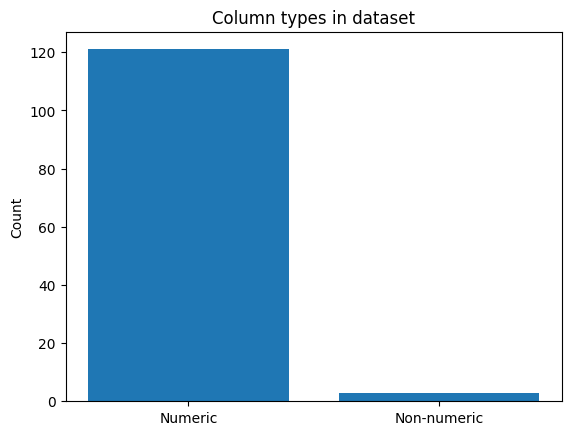

In [125]:
plt.figure()
plt.bar(["Numeric", "Non-numeric"], [len(num_cols), len(cat_cols)])
plt.title("Column types in dataset")
plt.ylabel("Count")
plt.show()


## Target Variable

In [126]:
df["GeregistreerdeMisdrijven_1"].describe()

count    14494.000000
mean        54.725611
std        121.275987
min          0.000000
25%          8.000000
50%         22.000000
75%         57.000000
max       3714.000000
Name: GeregistreerdeMisdrijven_1, dtype: float64

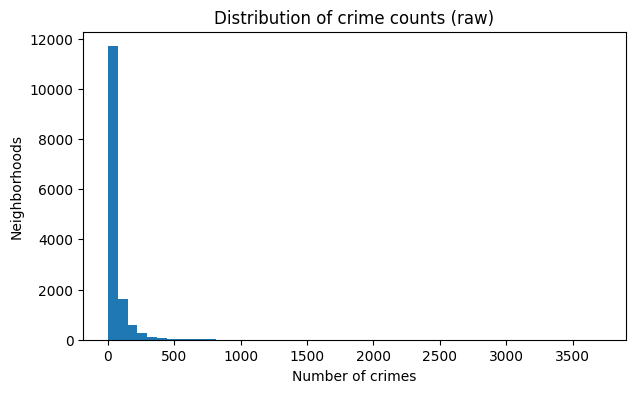

In [127]:
plt.figure(figsize=(7,4))
plt.hist(df["GeregistreerdeMisdrijven_1"], bins=50)
plt.title("Distribution of crime counts (raw)")
plt.xlabel("Number of crimes")
plt.ylabel("Neighborhoods")
plt.show()


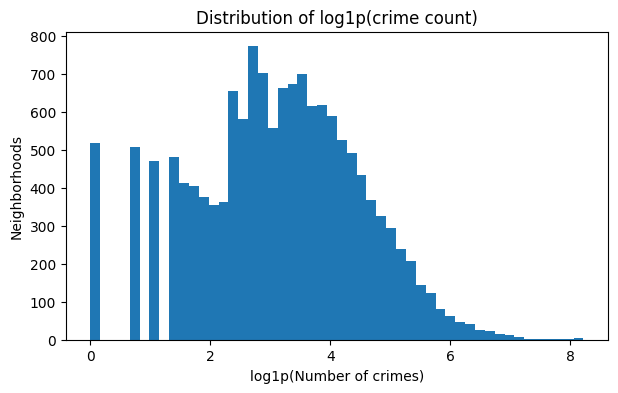

In [128]:
plt.figure(figsize=(7,4))
plt.hist(np.log1p(df["GeregistreerdeMisdrijven_1"]), bins=50)
plt.title("Distribution of log1p(crime count)")
plt.xlabel("log1p(Number of crimes)")
plt.ylabel("Neighborhoods")
plt.show()


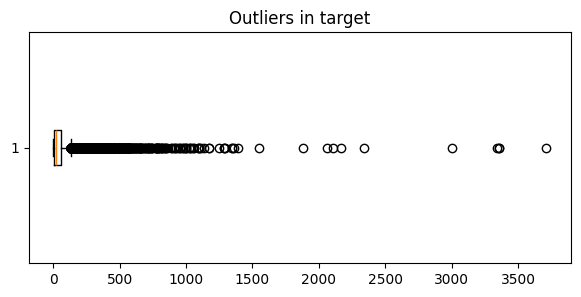

In [129]:
plt.figure(figsize=(7,3))
plt.boxplot(df["GeregistreerdeMisdrijven_1"], vert=False)
plt.title("Outliers in target")
plt.show()

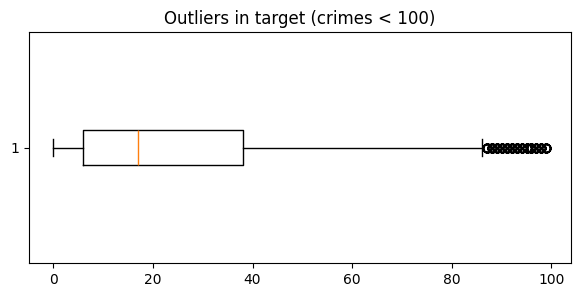

In [130]:
plt.figure(figsize=(7,3))
plt.boxplot(df[df["GeregistreerdeMisdrijven_1"] < 100]["GeregistreerdeMisdrijven_1"], vert=False)
plt.title("Outliers in target (crimes < 100)")
plt.show()

## Missing Data

In [131]:
# Missingness rate per column (share of NaNs)
miss = df.isna().mean()

In [132]:
# Count columns by missingness buckets
n_100 = (miss >= 0.999).sum()
n_20_99 = ((miss >= 0.20) & (miss < 0.999)).sum()
n_10_19 = ((miss >= 0.10) & (miss < 0.20)).sum()
n_1_9 = ((miss >= 0.01) & (miss < 0.10)).sum()
n_less0 = ((miss < 0.01) & (miss > 0)).sum()
n_0 = (miss == 0).sum()

print(f"Columns with 100% missing: {n_100}")
print(f"Columns with 20-99% missing: {n_20_99}")
print(f"Columns with 10-19% missing: {n_10_19}")
print(f"Columns with 1-9% missing: {n_1_9}")
print(f"Columns with <1% missing: {n_less0}")
print(f"Columns with 0 missing: {n_0}")
print(f"Total columns: {len(df.columns)}")

Columns with 100% missing: 27
Columns with 20-99% missing: 7
Columns with 10-19% missing: 26
Columns with 1-9% missing: 10
Columns with <1% missing: 6
Columns with 0 missing: 48
Total columns: 124


In [133]:
miss = df.isna().mean().sort_values(ascending=False)
miss.head(30)

p_hh_osm       1.000000
p_arb_wn       1.000000
m_hh_ver       1.000000
p_wmo_t        1.000000
p_hh_120       1.000000
p_jz_tn        1.000000
a_jz_tn        1.000000
a_opl_bvm      1.000000
a_opl_hvm      1.000000
p_hh_110       1.000000
a_opl_hw       1.000000
a_arb_wz       1.000000
a_wmo_t        1.000000
p_arb_pp       1.000000
p_arb_wnv      1.000000
g_ink_pi       1.000000
p_hh_lkk       1.000000
p_hh_hi        1.000000
p_hh_li        1.000000
g_hh_sti       1.000000
p_ink_hi       1.000000
p_ink_li       1.000000
a_lp_pub       1.000000
g_ink_po       1.000000
a_inkont       1.000000
p_arb_zs       1.000000
p_arb_wnf      1.000000
p_stadsv       0.925003
p_won_m_ag     0.300400
p_won_z_ag     0.300400
dtype: float64

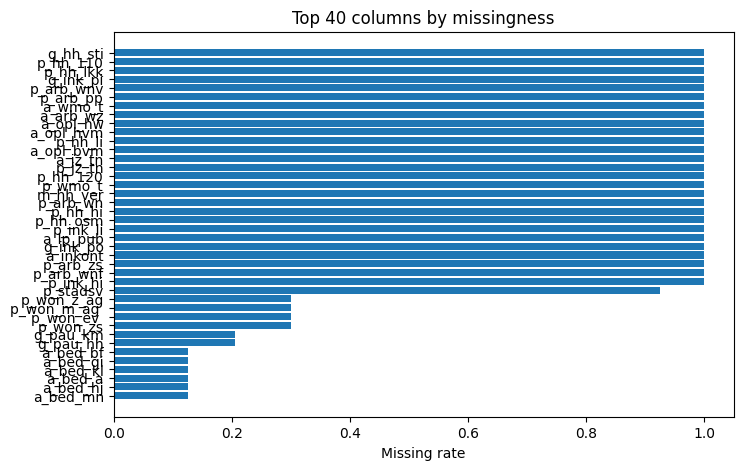

In [134]:
top = miss.head(40).sort_values()

plt.figure(figsize=(8,5))
plt.barh(top.index, top.values)
plt.title("Top 40 columns by missingness")
plt.xlabel("Missing rate")
plt.show()


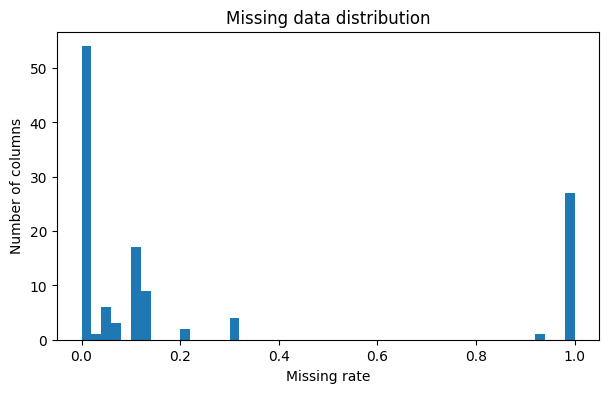

In [135]:
plt.figure(figsize=(7,4))
plt.hist(miss, bins=50)
plt.title("Missing data distribution")
plt.xlabel("Missing rate")
plt.ylabel("Number of columns")
plt.show()

In [172]:
total = len(miss)

def show(label, condition):
    count = miss[condition].count()
    perc = round(count / total * 100, 2)
    print(label)
    print(count, "columns")
    print(perc, "%", "\n")

show("100% missing", miss >= 0.999)
show("15-99% missing", (miss >= 0.15) & (miss < 0.999))
show("10-15% missing", (miss >= 0.1) & (miss < 0.15))
show("1-9% missing", (miss < 0.1) & (miss != 0))
show("Nothing missing", miss == 0)

100% missing
27 columns
21.77 % 

15-99% missing
7 columns
5.65 % 

10-15% missing
26 columns
20.97 % 

1-9% missing
16 columns
12.9 % 

Nothing missing
48 columns
38.71 % 



In [156]:
cols_over_15pct_missing = miss[miss > 0.15].index.tolist()
print(cols_over_15pct_missing)

['p_hh_osm', 'p_arb_wn', 'm_hh_ver', 'p_wmo_t', 'p_hh_120', 'p_jz_tn', 'a_jz_tn', 'a_opl_bvm', 'a_opl_hvm', 'p_hh_110', 'a_opl_hw', 'a_arb_wz', 'a_wmo_t', 'p_arb_pp', 'p_arb_wnv', 'g_ink_pi', 'p_hh_lkk', 'p_hh_hi', 'p_hh_li', 'g_hh_sti', 'p_ink_hi', 'p_ink_li', 'a_lp_pub', 'g_ink_po', 'a_inkont', 'p_arb_zs', 'p_arb_wnf', 'p_stadsv', 'p_won_m_ag ', 'p_won_z_ag', 'p_won_ev ', 'p_won_zs', 'g_pau_km', 'g_pau_hh']


In [173]:
cols_under_15pct_missing = miss[(miss <= 0.15) & (miss > 0)].index.tolist()
print(cols_under_15pct_missing)
print("Missing under 15%:", len(cols_under_15pct_missing))

['a_bed_hj', 'a_bed_a', 'a_bed_bf', 'a_bed_gi', 'a_bed_kl', 'a_bed_mn', 'a_bed_oq', 'a_bed_ru', 'g_wozbag', 'p_ov_hw', 'p_koopw', 'p_huurw', 'p_wcorpw', 'p_bj_mi10', 'p_bj_me10', 'p_1gezw_2w', 'p_leegsw', 'p_mgezw', 'p_1gezw_hvw', 'p_1gezw_hw', 'p_1gezw_tw', 'p_1gezw', 'a_soz_ow', 'a_soz_wb', 'a_soz_ww', 'a_soz_ao', 'g_gas', 'g_ele_tr', 'g_ele', 'g_afs_sc', 'g_3km_sc', 'g_afs_hp', 'g_afs_gs', 'g_afs_kv', 'bev_dich', 'g_hhgro', 'pst_dekp', 'pst_mvp', 'ste_oad', 'ste_mvs', 'p_ste', 'p_geb']
Missing under 15%: 42


## Population column

In [139]:
pop_col = df["a_inw"]

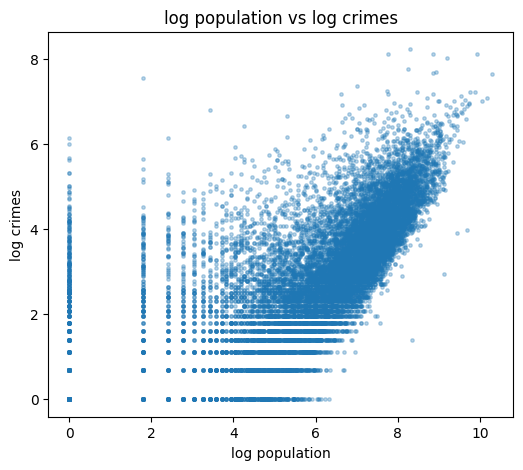

In [140]:
x = pop_col
y = df["GeregistreerdeMisdrijven_1"]

plt.figure(figsize=(6,5))
plt.scatter(np.log1p(x), np.log1p(y), s=6, alpha=0.3)
plt.title("log population vs log crimes")
plt.xlabel("log population")
plt.ylabel("log crimes")
plt.show()


## Feature Behavior

In [141]:
# Skewness of numeric features (exclude obvious identifiers/targets)
exclude = {
    'crime_count', 'log_crime_count', 'population', 'population_zero',
    'ID', 'merge_key', 'gwb_code', 'gwb_code_10', 'gwb_code_8'
}

num = df.select_dtypes(include=['number']).copy()
cols = [c for c in num.columns if c not in exclude]

skew = num[cols].skew(numeric_only=True).abs().sort_values(ascending=False)
# (Removed) verbose printout.


### Skewness

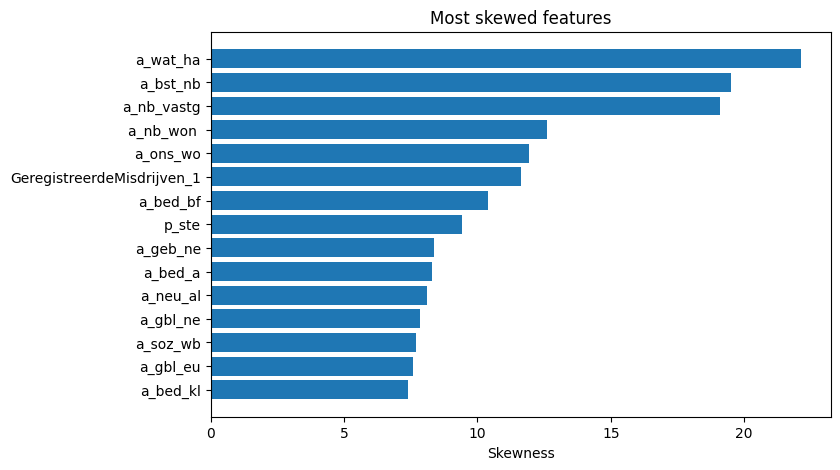

In [142]:
top = skew.head(15).sort_values()

plt.figure(figsize=(8,5))
plt.barh(top.index, top.values)
plt.title("Most skewed features")
plt.xlabel("Skewness")
plt.show()


### Correlation with target

In [143]:
corr = df[num_cols].corrwith(df["GeregistreerdeMisdrijven_1"]).sort_values(key=lambda s: s.abs(), ascending=False)
corr.head(15)

GeregistreerdeMisdrijven_1    1.000000
a_bed_gi                      0.750887
a_bedv                        0.730882
a_1p_hh                       0.727196
a_bed_ru                      0.701376
a_bed_hj                      0.670796
a_25_44                       0.670075
a_ongeh                       0.656121
a_hh                          0.656103
a_eur_al                      0.652701
a_gbl_eu                      0.646120
a_bed_mn                      0.645086
a_gbl_ne                      0.637253
a_15_24                       0.632274
a_woning                      0.631723
dtype: float64

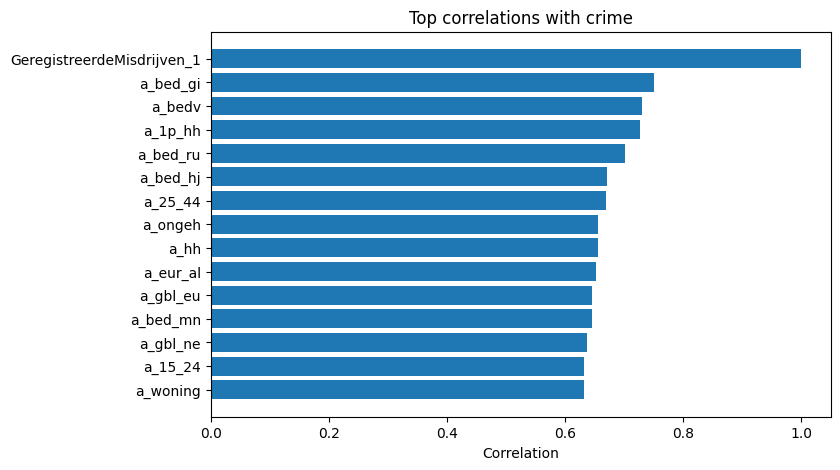

In [144]:
top = corr.head(15).sort_values()

plt.figure(figsize=(8,5))
plt.barh(top.index, top.values)
plt.title("Top correlations with crime")
plt.xlabel("Correlation")
plt.show()


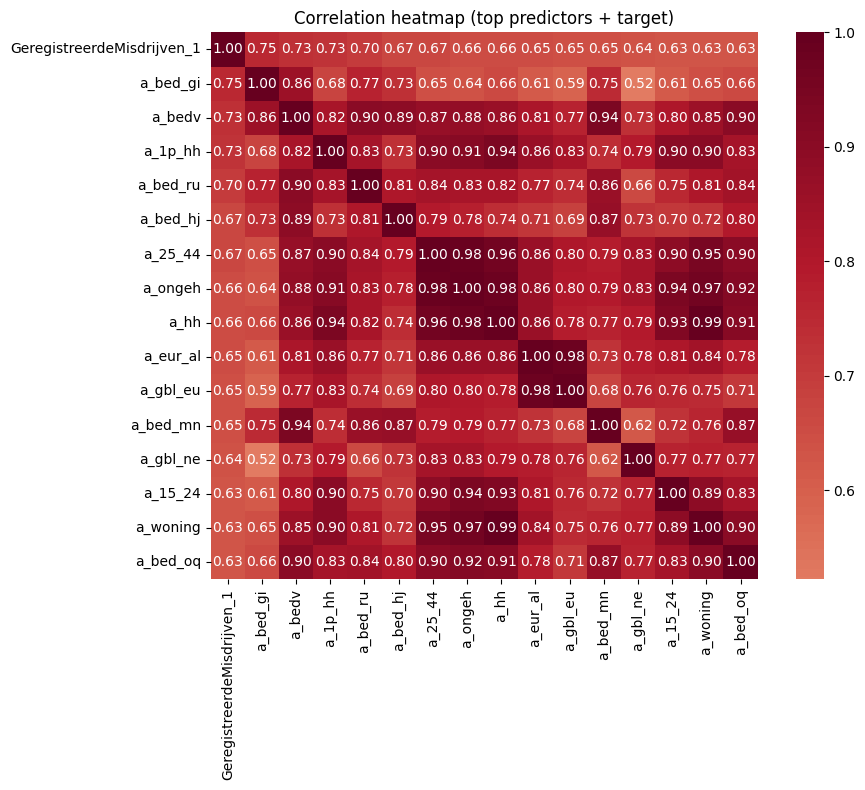

In [145]:
# Correlation heatmap: top 15 predictors + target (subset for readability)
import seaborn as sns
top_vars = corr.head(16).index.tolist()  # top 15 + target
heatmap_data = df[top_vars].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(heatmap_data, annot=True, fmt=".2f", cmap="RdBu_r", center=0, square=True)
plt.title("Correlation heatmap (top predictors + target)")
plt.tight_layout()
plt.show()

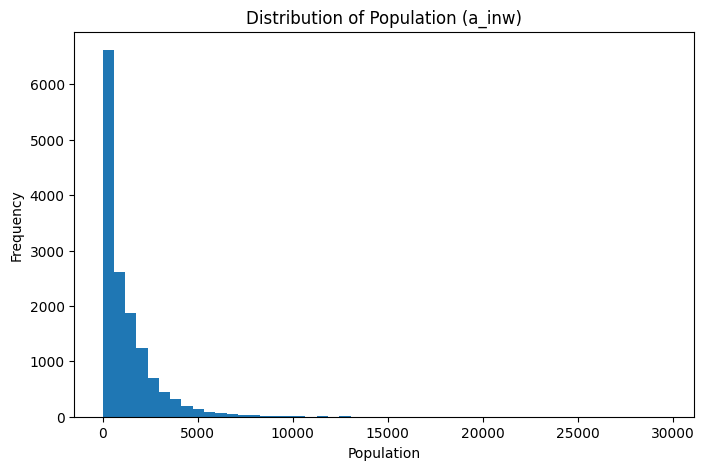

In [146]:
plt.figure(figsize=(8,5))
plt.hist(df["a_inw"], bins=50)
plt.title("Distribution of Population (a_inw)")
plt.xlabel("Population")
plt.ylabel("Frequency")
plt.show()

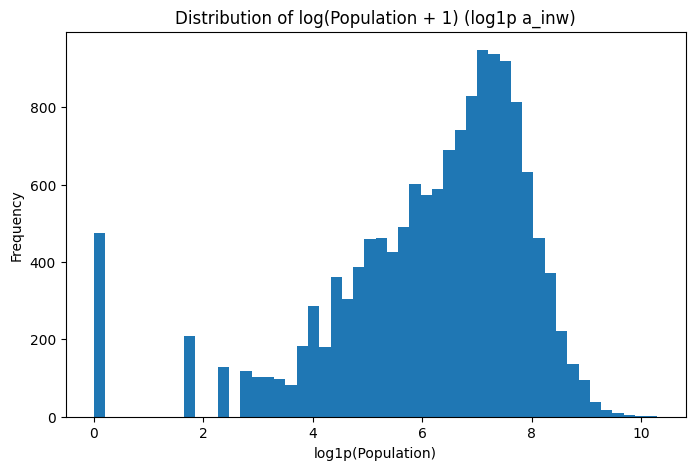

In [147]:
plt.figure(figsize=(8,5))
plt.hist(np.log1p(df["a_inw"]), bins=50)
plt.title("Distribution of log(Population + 1) (log1p a_inw)")
plt.xlabel("log1p(Population)")
plt.ylabel("Frequency")
plt.show()

In [153]:
df["a_inw"].describe()

count    14494.000000
mean      1227.927763
std       1590.640045
min          0.000000
25%        185.000000
50%        715.000000
75%       1695.000000
max      29660.000000
Name: a_inw, dtype: float64